# Top 10 best performing proto-models (real database)

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import ast
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
import sys,os,copy,glob
sys.path.append(os.path.abspath('../smodels'))
sys.path.append(os.path.abspath('../'))
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from tester.predictor import Predictor
from tester.combiner import Combiner
#from walker.hiscore import Hiscore
from smodels.experiment.databaseObj import Database
from smodels.base import runtime
from smodels.base.physicsUnits import fb
runtime._experimental = True
from names import particleLabels
from sparticleNames import SParticleNames

In [5]:
#read tar file (in compressed format since it is heavy)
import tarfile
walks = np.arange(501,551) #walker ids (total 50)
tar_file = "../real_run/all_walks.tar.gz"

In [6]:
hiscore_proto = {}
with tarfile.open(tar_file, 'r:gz') as tar:
    for ind,member in enumerate(tar.getmembers()):
        print("\n",member.name)
        dictfile = tar.extractfile(member)
        try:
            content = dictfile.read().decode('utf-8')
            di = eval(content)  
        except Exception as e:
            print(f"Skipping {member.name} due to error: {e}")
            continue
        n_acc = 0
        
        last_step = di[-1]['step']
        maxK = -1500
        hiscore_proto[ind+1] = {}
        maxProto = {}
        for i, d in enumerate(di):
            if d == {}:continue
            step = d['step']
            if step < 3500: continue #3500 steps burn-in
            acc = d['Accepted']
            
            if acc == 0:
                K = d['K']
                if K > maxK:
                    maxK = K
                    maxProto = d
        #record the best performing proto-models
        hiscore_proto[ind+1] = maxProto
                


 all_dict501.dict

 all_dict502.dict

 all_dict503.dict

 all_dict504.dict

 all_dict505.dict

 all_dict506.dict

 all_dict507.dict

 all_dict508.dict

 all_dict509.dict

 all_dict510.dict

 all_dict511.dict

 all_dict512.dict

 all_dict513.dict

 all_dict514.dict

 all_dict515.dict

 all_dict516.dict

 all_dict517.dict

 all_dict518.dict

 all_dict519.dict

 all_dict520.dict

 all_dict521.dict

 all_dict522.dict

 all_dict523.dict

 all_dict524.dict

 all_dict525.dict

 all_dict526.dict

 all_dict527.dict

 all_dict528.dict

 all_dict529.dict

 all_dict530.dict

 all_dict531.dict

 all_dict532.dict

 all_dict533.dict

 all_dict534.dict

 all_dict535.dict

 all_dict536.dict

 all_dict537.dict

 all_dict538.dict

 all_dict539.dict

 all_dict540.dict

 all_dict541.dict

 all_dict542.dict

 all_dict543.dict

 all_dict544.dict

 all_dict545.dict

 all_dict546.dict

 all_dict547.dict

 all_dict548.dict

 all_dict549.dict

 all_dict550.dict


In [8]:
#did not initially record best_combination, later tested for best performing proto-models separately
bc = None
for ind,proto in hiscore_proto.items():
    if "best_comb" in proto.keys(): 
        bc = proto["best_comb"]
    
    else: 
        print(ind, proto)


3 {'masses': {1000022: 100.92, 1000023: 131.72, 1000024: 161.21}, 'ssmultipliers': {(-1000024, 1000024): 0.91, (1000022, 1000023): 0.31, (1000022, 1000024): 1.55, (1000023, 1000023): 0.92, (1000023, 1000024): 3.94}, 'decays': {1000022: {}, 1000023: {(1000022, 12, 12): 1.0}, 1000024: {(1000022, 2, 1): 1.0}}, 'Accepted': 0, 'K': 18.29, 'TL': 22.31, 'step': 4947, 'muhat': 1.0, 'accratio': 0.0}
9 {'masses': {1000022: 141.62, 1000023: 437.38}, 'ssmultipliers': {(1000022, 1000022): 1.64, (1000023, 1000023): 0.32}, 'decays': {1000022: {}, 1000023: {(1000022, 25): 1.0}}, 'Accepted': 0, 'K': 15.9, 'TL': 18.4, 'step': 3549, 'muhat': 1.0, 'accratio': 0.0}
16 {'masses': {1000022: 109.3, 1000023: 422.88}, 'ssmultipliers': {(1000022, 1000022): 1.21, (1000022, 1000023): 0.96, (1000023, 1000023): 0.28}, 'decays': {1000022: {}, 1000023: {(1000022, 25): 1.0}}, 'Accepted': 0, 'K': 16.32, 'TL': 19.07, 'step': 5243, 'muhat': 1.0, 'accratio': 0.0}
24 {'masses': {1000022: 252.77, 1000023: 651.26, 1000025: 78

In [11]:
bc_dict = [{"walkerid": 3, "best_comb": 'CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em)'},
            {"walkerid": 9, "best_comb": "CMS-EXO-20-004(comb),CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(em)"},
            {"walkerid": 16, "best_comb": 'CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-SUS-20-004(comb)'},
            {"walkerid": 24, "best_comb": 'CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-EXO-20-004(comb),CMS-SUS-13-012(em),ATLAS-SUSY-2018-41(comb)'},
            {"walkerid": 31, "best_comb": 'CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-SUS-20-004(comb),CMS-SUS-13-012(em)'},
            {"walkerid": 38, "best_comb": 'CMS-EXO-20-004(comb),CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-SUS-13-012(em)'},
        ]


In [12]:
bc = None
hiscore_list = []
#remove unnecessary information from dict files
keys_to_remove = {'accratio', 'muhat', 'Accepted'}

for ind,proto in hiscore_proto.items():
    
    if "best_comb" in proto.keys(): 
        bc = proto["best_comb"]
    elif ind == 3: 
        proto["best_comb"] = 'CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em)'
    else: 
        print(ind)
        bc = [di['best_comb'] for di in bc_dict if di['walkerid']==ind]
        proto.update({"best_comb":bc[0]})
        print(ind, proto)
    
    for k in keys_to_remove: proto.pop(k,None)
    proto.update({'walkerid':ind})

    hiscore_list.append(proto)
    


9
9 {'masses': {1000022: 141.62, 1000023: 437.38}, 'ssmultipliers': {(1000022, 1000022): 1.64, (1000023, 1000023): 0.32}, 'decays': {1000022: {}, 1000023: {(1000022, 25): 1.0}}, 'Accepted': 0, 'K': 15.9, 'TL': 18.4, 'step': 3549, 'muhat': 1.0, 'accratio': 0.0, 'best_comb': 'CMS-EXO-20-004(comb),CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(em)'}
16
16 {'masses': {1000022: 109.3, 1000023: 422.88}, 'ssmultipliers': {(1000022, 1000022): 1.21, (1000022, 1000023): 0.96, (1000023, 1000023): 0.28}, 'decays': {1000022: {}, 1000023: {(1000022, 25): 1.0}}, 'Accepted': 0, 'K': 16.32, 'TL': 19.07, 'step': 5243, 'muhat': 1.0, 'accratio': 0.0, 'best_comb': 'CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-SUS-20-004(comb)'}
24
24 {'masses': {1000022: 252.77, 1000023: 651.26, 1000025: 786.89}, 'ssmultipliers': {(1000022, 1000022): 5.42, (1000022, 1000023): 0.47, (1000023, 1000023): 0.54, (1000023, 1000025): 11.56, (1000025, 1000025): 0.48}, 'decays': {1000022: {}, 1000023: {(1000022, 25): 1.0}, 1000025: {(1

In [9]:
#set colors
colorDict = {}
colorDict[1000022] = 'dodgerblue'
colorDict[1000023] = 'blue'
colorDict[1000025] = 'navy'

colorDict[1000024] = 'limegreen'
colorDict[1000037] = 'darkgreen'

In [13]:
#write to dict file
from pprint import pformat
with open("../real_run/best_perf_proto.dict","w") as f:
    f.write(pformat(hiscore_list, width=100))
    #hiscore_proto = eval(f.read())

FileNotFoundError: [Errno 2] No such file or directory: '../real_run/best_perf_proto.dict'

In [14]:
# create protomodel objects
from base.runEnviron import RunEnviron
RunEnviron.create()
environ = RunEnviron()

def fromDict(walkid, inputDict):
    
    p = ProtoModel(walkerid=walkid, environ=environ)
    for key,v in inputDict.items():
        setattr(p,key,copy.deepcopy(v))
        if "best_comb" in inputDict.keys(): p.description = inputDict['best_comb']
        else: p.description = None
        
    return p

pList = [fromDict(walkerid, pDict) for walkerid,pDict in hiscore_proto.items()]
proto_high = sorted(pList, key = lambda p: p.K, reverse=True)[:10]

for p in proto_high:
    print(p.walkerid, p.K, p.step, p.masses)
    print( p.description)

3 18.29 4947 {1000022: 100.92, 1000023: 131.72, 1000024: 161.21}
CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em)
24 16.96 5136 {1000022: 252.77, 1000023: 651.26, 1000025: 786.89}
CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-EXO-20-004(comb),CMS-SUS-13-012(em),ATLAS-SUSY-2018-41(comb)
18 16.46 11542 {1000022: 278.18, 1000023: 526.16, 1000024: 524.34}
ATLAS-EXOT-2018-06(em),CMS-EXO-20-004(comb),CMS-SUS-20-004(comb),ATLAS-SUSY-2016-24(em),ATLAS-SUSY-2019-08(comb),ATLAS-SUSY-2013-11(em),CMS-SUS-13-012(em),CMS-SUS-16-039-agg(comb)
41 16.42 18369 {1000022: 74.25, 1000023: 426.84}
CMS-EXO-20-004(comb),CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(em)
11 16.41 4050 {1000022: 157.19, 1000023: 436.15}
CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-SUS-20-004(comb),CMS-SUS-13-012(em)
16 16.32 5243 {1000022: 109.3, 1000023: 422.88}
CMS-EXO-20-004(comb),ATLAS-EXOT-2018-06(em),CMS-SUS-20-004(comb)
34 16.31 9117 {1000022: 108.89, 1000023: 450.8}
CMS-EXO-20-004(comb),CMS-SUS-20-004(comb),ATLAS-EXOT-2018-06(

In [19]:
for proto in proto_high:
    walkerid = proto.walkerid
    step = proto.step
    print(walkerid,proto,'step=',step)
    
Kavg = np.array([proto.K for proto in proto_high]).mean()
Kstd = np.array([proto.K for proto in proto_high]).std()
print('K (avg) = %1.2f +- %1.2f' %(Kavg,Kstd))

3 ProtoModel (X1Z,X2Z,X1W): K = 18.29, TL = 22.31 step= 4947
24 ProtoModel (X1Z,X2Z,X3Z): K = 16.96, TL = 21.99 step= 5136
18 ProtoModel (X1Z,X2Z,X1W): K = 16.46, TL = 20.49 step= 11542
41 ProtoModel (X1Z,X2Z): K = 16.42, TL = 19.17 step= 18369
11 ProtoModel (X1Z,X2Z): K = 16.41, TL = 19.66 step= 4050
16 ProtoModel (X1Z,X2Z): K = 16.32, TL = 19.07 step= 5243
34 ProtoModel (X1Z,X2Z): K = 16.31, TL = 19.06 step= 9117
8 ProtoModel (X1Z,X2Z): K = 16.29, TL = 19.54 step= 14502
29 ProtoModel (X1Z,X2Z): K = 16.28, TL = 19.03 step= 11451
23 ProtoModel (X1Z,X2Z): K = 16.27, TL = 19.02 step= 5341
K (avg) = 16.60 +- 0.60


In [40]:
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Palatino'
plt.rcParams['font.weight'] = '700'
plt.rcParams['axes.labelweight'] = '700'

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [15]:
#Get all particles which appears in all models:
particles = []
analyses = []
#modelList = np.array(list(protomodelsDict.items()))
#runs = modelList[:,0]
#modelList = modelList[:,1]
for proto in proto_high:
    particles += proto.unFrozenParticles()
    ana = proto.description.split(',')
    analyses += ana
    #print(analyses)
particles = list(set(particles))
analyses = sorted(list(set(analyses)))

#Build useful dataset:
walkerid_values = np.array([f"{proto.walkerid}:{proto.step}" for proto in proto_high])
nparticles = np.array([len(proto.unFrozenParticles()) for proto in proto_high])
Kvalues = np.array([proto.K if (proto.K and proto.K > 0) else 0.0 for proto in proto_high])
TLvalues = np.array([proto.TL if (proto.TL and proto.TL > 0) else 0.0 for proto in proto_high])
masses = dict([[pid,[]] for pid in particles])
for proto in proto_high:
    for pid in masses:
        if pid in proto.masses:
            masses[pid].append(proto.masses[pid])
        else:
            masses[pid].append(-100.0)
for pid in masses:
    masses[pid] = np.array(masses[pid])
dataDict = {'walkerid': walkerid_values, 'K' : Kvalues, 'TL': TLvalues, 'nparticles' : nparticles}
dataDict.update(masses) 
bestCombo_values = np.array([proto.description for proto in proto_high])
dataDict.update({"bestCombo":bestCombo_values}) 

df = pd.DataFrame(dataDict)

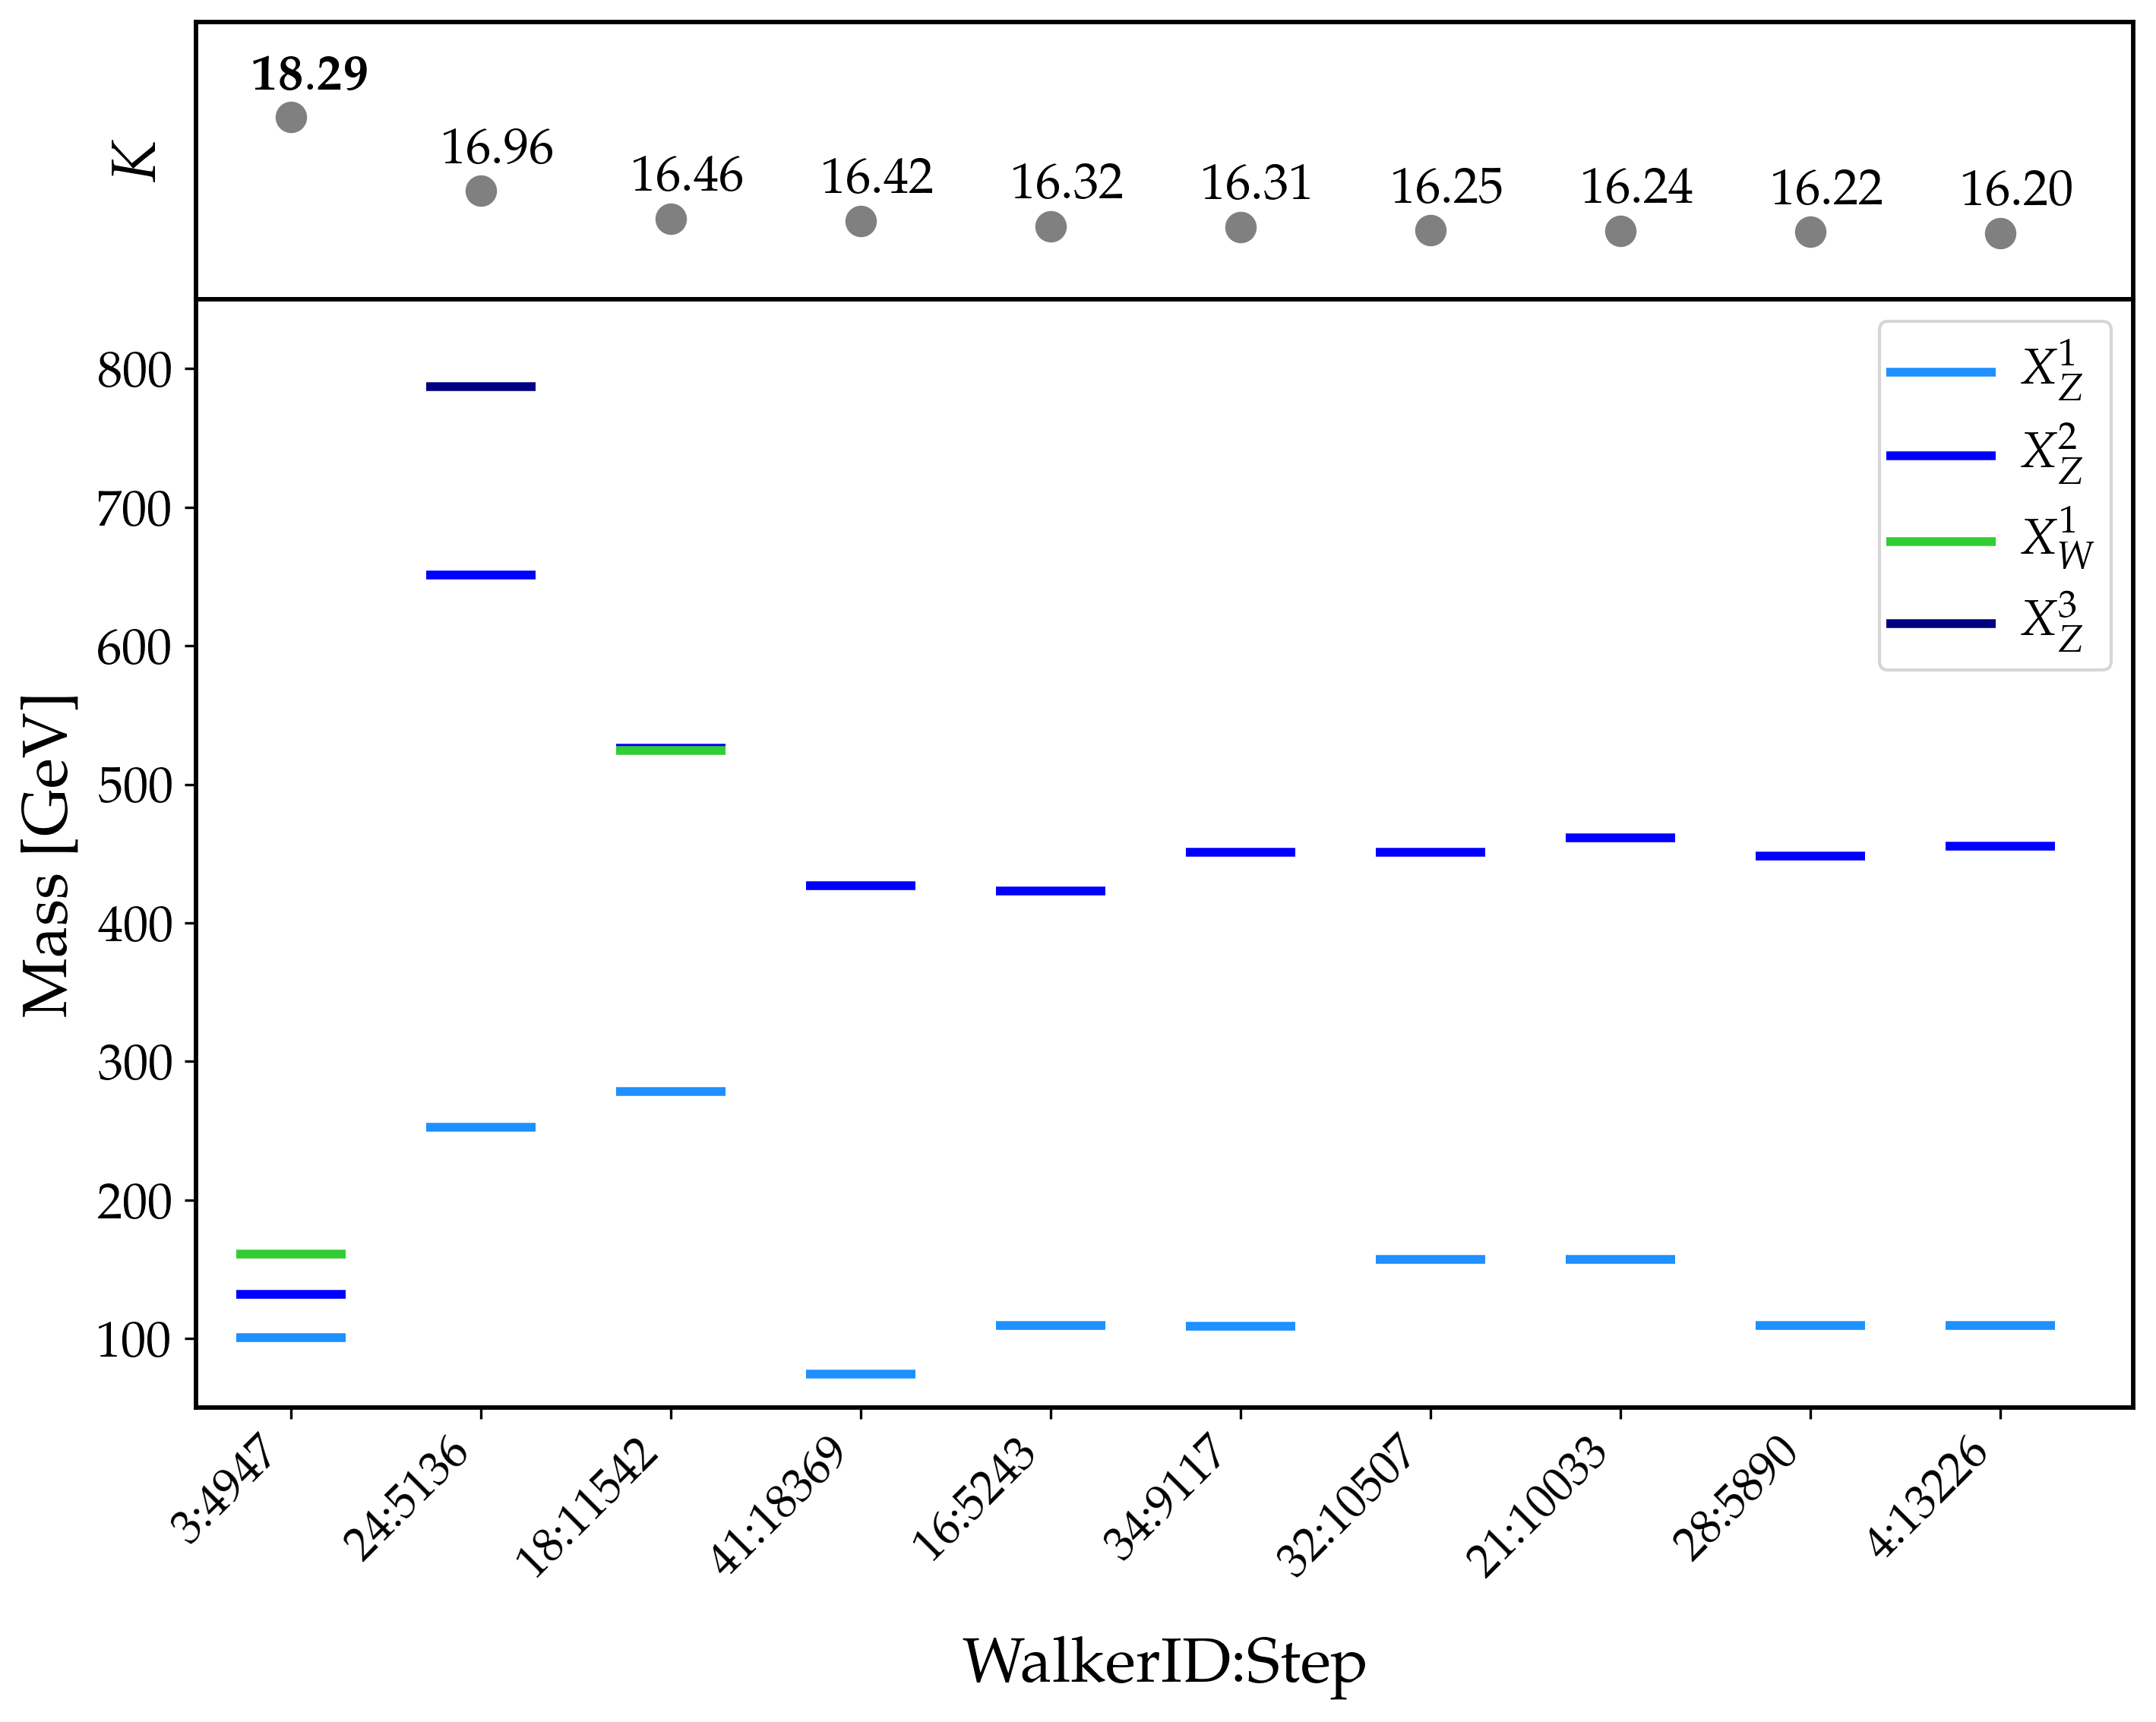

In [42]:
particleLabels[1000024] = "$X_{W}^{1}$"
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

pids = sorted(list(masses.keys()))

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
axarr[0].set_ylabel(r'$K$', fontsize=20)
axarr[0].set_ylim(15.0,20.0)
axarr[0].set_yticks([])
for i,row in df.iterrows():
    index = np.where(walkerid_values == row['walkerid'])[0][0] 
    if row['K'] == max(df['K']):        
        axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['K'],(index-0.2,row['K']+0.5),
                          fontsize=16)

    else:
        axarr[0].annotate(r'%1.2f' %row['K'],(index-0.2,row['K']+0.5),fontsize=16)


for pid in pids:    
    data = df
    sns.scatterplot(x=data['walkerid'],y=data[pid], s=1200, marker='_',
                    label=r'$%s$' %(particleLabels[pid]), legend=True,
                    c=[colorDict[pid]],ax=axarr[1])
    index = [np.where(walkerid_values == d['walkerid'])[0][0] for j,d in data.iterrows()]


axarr[1].set_ylim(50.,850.0)
axarr[1].set_xlim(-0.5,9.7)
axarr[1].set_xlabel('WalkerID:Step', fontsize=20, labelpad=15)
#axarr[1].xaxis.label.set_fontweight(7000)
axarr[1].set_ylabel('Mass [GeV]', fontsize=20)
#axarr[1].yaxis.label.set_fontweight("bold")
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=15, rotation=45, ha='right')
leg = axarr[1].legend()
plt.setp(leg.get_texts(), fontsize=16)
plt.show()

['ATLAS-SUSY-2018-41(comb)', 'ATLAS-EXOT-2018-06(em)', 'ATLAS-SUSY-2016-24(em)', 'CMS-SUS-13-012(em)', 'CMS-SUS-20-004(comb)', 'ATLAS-SUSY-2019-08(comb)', 'CMS-SUS-16-039-agg(comb)', 'ATLAS-SUSY-2013-11(em)', 'CMS-EXO-20-004(comb)']


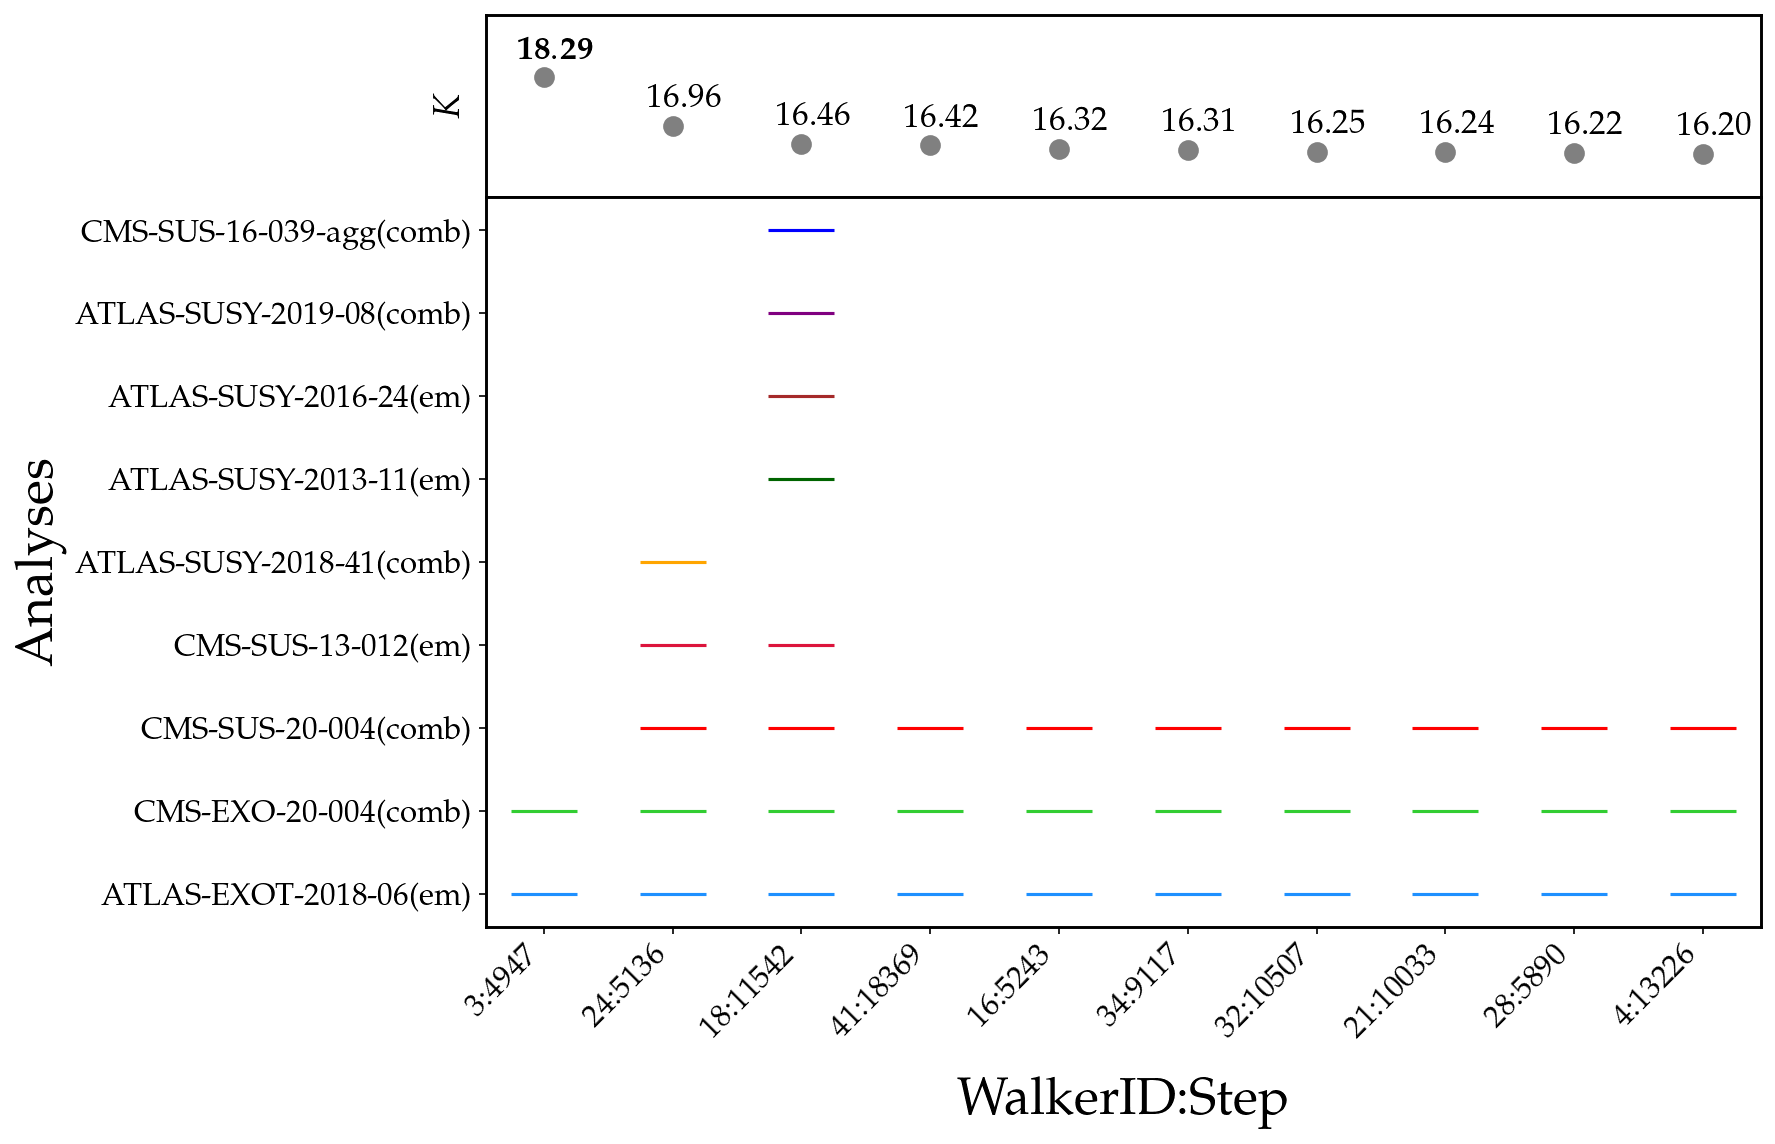

In [69]:
def color_analyses(comb_list):

    colors = sns.color_palette('bright',n_colors=len(comb_list))
    colorAna['ATLAS-EXOT-2018-06(em)'] = 'dodgerblue'
    colorAna['CMS-EXO-20-004(comb)'] = 'limegreen'
    colorAna['ATLAS-SUSY-2018-41(comb)'] = 'orange'
    colorAna['CMS-SUS-13-012(em)'] = 'crimson'
    colorAna['CMS-SUS-20-004(comb)'] = 'red'
    colorAna['ATLAS-SUSY-2013-11(em)'] = 'darkgreen'
    colorAna['ATLAS-SUSY-2016-24(em)'] = 'brown'
    colorAna['ATLAS-SUSY-2019-08(comb)'] = 'purple'
    colorAna['CMS-SUS-16-039-agg(comb)'] = 'blue'
    #['ATLAS-EXOT-2018-06(em)', 'CMS-SUS-16-039-agg(comb)', 'ATLAS-SUSY-2018-41(comb)', 'ATLAS-SUSY-2013-11(em)', 'CMS-SUS-20-004(comb)', 'CMS-EXO-20-004(comb)', 'ATLAS-SUSY-2016-24(em)', 'CMS-SUS-13-012(em)', 'ATLAS-SUSY-2019-08(comb)']

    #colorDict = dict(zip(comb_list,colors))
    return colorAna


f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

pids = sorted(list(masses.keys()))

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
axarr[0].set_ylabel(r'$K$')
axarr[0].set_ylim(15.0,20.0)
axarr[0].set_yticks([])
comb_list = set()
for i,row in df.iterrows():
    index = np.where(walkerid_values == row['walkerid'])[0][0] 
    if row['K'] == max(df['K']):        
        axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['K'],(index-0.2,row['K']+0.5),
                          fontsize=16)

    else:
        axarr[0].annotate(r'$%1.2f$' %row['K'],(index-0.2,row['K']+0.5),fontsize=16)
    bC = sorted(row['bestCombo'].split(','))
    #print(bC)
    for b in bC: comb_list.add(b)

sortedAna = ['ATLAS-EXOT-2018-06(em)','CMS-EXO-20-004(comb)','CMS-SUS-20-004(comb)', 'CMS-SUS-13-012(em)', 'ATLAS-SUSY-2018-41(comb)', 'ATLAS-SUSY-2013-11(em)', 'ATLAS-SUSY-2016-24(em)', 'ATLAS-SUSY-2019-08(comb)', 'CMS-SUS-16-039-agg(comb)']
y_positions = list(range(len(sortedAna)))
axarr[1].set_yticks(y_positions)
axarr[1].set_yticklabels(sortedAna,  fontsize=15)
comb_list = list(comb_list)
print(comb_list)
colorAna = color_analyses(comb_list)
for i,row in df.iterrows():
    bC = sorted(row['bestCombo'].split(','))
    for j, b in enumerate(bC):
        y_position = [ind for (ind,sA) in zip(y_positions, sortedAna) if sA==b][0]
        axarr[1].scatter(row['walkerid'], y_position, marker='_', s=1000, c=[colorAna[b]] )
        index2 = analyses.index(b)
axarr[1].set_xlabel('WalkerID:Step', fontsize=25, labelpad=15)
axarr[1].set_ylabel('Analyses', fontsize=25)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()), fontsize=15, rotation=45, ha='right')


plt.show()